# Plackett-Burman screening and ANOVA reconstruction

This notebook reconstructs the screening phase reported in the adaptive winglet study and organizes it as a transparent DOE workflow.

## Theoretical context

A 12-run Plackett-Burman (PB) design is a two-level screening design used to identify the most influential factors with a small experimental budget. In this phase, the objective is not detailed response-surface modeling; it is factor prioritization.

Main assumptions used in this reconstruction:
- factors are coded at two levels ($-1,+1$),
- main effects dominate during screening,
- interaction effects are not explicitly estimated and are absorbed into residual variation,
- the response is drag coefficient $C_D$.

## What this notebook delivers

1. Build the PB design matrix and response vector.
2. Compute contrasts, effects, and sums of squares for each factor.
3. Construct full-model ANOVA quantities (Model, Error, Total).
4. Interpret factor significance through $F$-tests and right-tail $p$-values.
5. Visualize significance using $F$-distribution and Pareto-style plots.
6. Build a reduced model by removing the least significant factor and compare model-level significance.


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

# Global typography for charts: Times-like serif + STIX math text.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
})

# Try scipy first. If unavailable in a given JupyterLite build, the notebook still runs,
# but p-values and the F-density plot will need scipy.
try:
    from scipy.stats import f as f_dist
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


def factor_to_tex(name: str, wrap_math: bool = False) -> str:
    """Convert X2_sweep_angle -> X_{2}(sweep\\ angle) for matplotlib math text."""
    if "_" in name and name.startswith("X"):
        code, label = name.split("_", 1)
        idx = code[1:]
        label_tex = label.replace("_", r"\ ")
        out = rf"X_{{{idx}}}\,(\mathrm{{{label_tex}}})"
    else:
        out = name.replace("_", r"\_")
    return rf"${out}$" if wrap_math else out


def factor_to_html(name: str) -> str:
    """Convert X2_sweep_angle -> X<sub>2</sub> (sweep angle) for HTML tables."""
    if "_" in name and name.startswith("X"):
        code, label = name.split("_", 1)
        idx = code[1:]
        label_html = label.replace("_", " ")
        return f"X<sub>{idx}</sub> ({label_html})"
    return name.replace("_", " ")


# Best-effort notebook CSS: make markdown/text/table output Times-like.
display(HTML("""
<style>
.markdown-body,
.jp-RenderedHTMLCommon,
.jp-RenderedMarkdown,
.rendered_html,
table.dataframe {
    font-family: "Times New Roman", Times, serif !important;
}
</style>
"""))

## Inputs and Experimental Encoding

This section defines the screening dataset used by the analysis:
- coded PB matrix for the seven geometric factors,
- measured response vector $C_D$ for the 12 runs.

Interpretation notes:
- each column of the coded matrix is one factor $X_i$,
- $+1$ and $-1$ denote the high and low physical settings,
- each run combines all factor levels according to the PB pattern.

You can replace the $C_D$ values with another dataset and rerun all cells to reproduce the same inferential pipeline on new observations.

In [80]:
# Coded 12-run PB design used in the paper
factors = ["X1_root_chord", "X2_sweep_angle", "X3_taper_ratio", "X4_height", "X5_cant", "X6_toe_angle", "X7_twist_angle"]

coded = np.array([
    [ -1,  -1,  -1,   1,   1,   1,  -1],  #1
    [  1,   1,  -1,   1,  -1,  -1,  -1],  #2
    [  1,  -1,   1,  -1,  -1,  -1,   1],  #3
    [  1,   1,   1,  -1,   1,   1,  -1],  #4
    [ -1,   1,   1,  -1,   1,  -1,  -1],  #5
    [ -1,   1,  -1,  -1,  -1,   1,   1],  #6
    [ -1,   1,   1,   1,  -1,   1,   1],  #7
    [  1,  -1,   1,   1,  -1,   1,  -1],  #8
    [  1,  -1,  -1,  -1,   1,   1,   1],  #9
    [ -1,  -1,   1,   1,   1,  -1,   1],  #10
    [ -1,  -1,  -1,  -1,  -1,  -1,  -1],  #11
    [  1,   1,  -1,   1,   1,  -1,   1],  #12
], dtype=int)

# Drag coefficient values from the paper
CD = np.array([
    0.020126,
    0.023634,
    0.023588,
    0.022778,
    0.022989,
    0.023436,
    0.023351,
    0.023626,
    0.022702,
    0.020402,
    0.023475,
    0.021289
], dtype=float)

df = pd.DataFrame(coded, columns=factors)
df.insert(0, "run", np.arange(1, 13))
df["CD"] = CD
df

,run,X1_root_chord,X2_sweep_angle,X3_taper_ratio,X4_height,X5_cant,X6_toe_angle,X7_twist_angle,CD
0,1,-1,-1,-1,1,1,1,-1,0.020126
1,2,1,1,-1,1,-1,-1,-1,0.023634
2,3,1,-1,1,-1,-1,-1,1,0.023588
3,4,1,1,1,-1,1,1,-1,0.022778
4,5,-1,1,1,-1,1,-1,-1,0.022989
5,6,-1,1,-1,-1,-1,1,1,0.023436
6,7,-1,1,1,1,-1,1,1,0.023351
7,8,1,-1,1,1,-1,1,-1,0.023626
8,9,1,-1,-1,-1,1,1,1,0.022702
9,10,-1,-1,1,1,1,-1,1,0.020402


## Core Formulas and Statistical Meaning

### 1) Factor effect estimation in PB screening

For each factor $X_i$:

$$
\mathrm{Contrast}_{X_i} = \sum_{r:\,X_i=+1} C_{D,r} - \sum_{r:\,X_i=-1} C_{D,r}
$$

$$
\mathrm{Effect}(X_i) = \frac{\mathrm{Contrast}_{X_i}}{6}
$$

The contrast measures the net response shift from low to high factor level. Dividing by 6 (half the number of runs in the $12$-run design) gives the estimated main effect.

$$
SS_{X_i} = \frac{\mathrm{Contrast}_{X_i}^2}{12}
$$

$$
MS_{X_i} = \frac{SS_{X_i}}{df_{X_i}}, \quad df_{X_i}=1
$$

### 2) Model partitioning for ANOVA

For the full PB main-effects model:

$$
SS_T = \sum_{r=1}^{12}\left(C_{D,r} - \overline{C_D}\right)^2
$$

$$
SS_M = \sum_{i=1}^{7} SS_{X_i}
$$

$$
SS_E = SS_T - SS_M
$$

Degrees of freedom:

$$
df_T = N - 1 = 11
$$

$$
df_M = 7
$$

$$
df_E = df_T - df_M = 4
$$

Residual mean square:

$$
MS_E = \frac{SS_E}{df_E}
$$

### 3) Hypothesis testing for each factor

$$
F_{X_i} = \frac{MS_{X_i}}{MS_E}
$$

$$
p_{X_i} = P\!\left(F_{1,4} \ge F_{X_i} \mid H_0\right)
$$

with null hypothesis $H_0$: factor $X_i$ has no main effect on $C_D$.

A small right-tail $p$-value indicates the observed $F_{X_i}$ is unlikely under $H_0$, so the factor is considered influential at the chosen significance level (typically $\alpha=0.05$).

In [81]:
N = len(CD)
mean_cd = CD.mean()

results = []
for j, name in enumerate(factors):
    signs = coded[:, j]
    contrast = float(np.sum(signs * CD))
    effect = contrast / 6.0
    ss = contrast**2 / 12.0
    results.append({
        "factor": name,
        "contrast": contrast,
        "effect": effect,
        "SS": ss,
        "df": 1
    })

results_df = pd.DataFrame(results)

SS_total = float(np.sum((CD - mean_cd)**2))
SS_model = float(results_df["SS"].sum())
df_total = N - 1
df_model = len(factors)
df_error = df_total - df_model
SS_error = SS_total - SS_model
MS_error = SS_error / df_error

results_df["MS"] = results_df["SS"] / results_df["df"]
results_df["F"] = results_df["MS"] / MS_error

if SCIPY_AVAILABLE:
    results_df["p_value"] = results_df["F"].apply(lambda x: float(f_dist.sf(x, 1, df_error)))
else:
    results_df["p_value"] = np.nan

summary = pd.DataFrame({
    "quantity": ["N", "mean(CD)", "SS_total", "SS_model", "SS_error", "df_total", "df_model", "df_error", "MS_error"],
    "value": [N, mean_cd, SS_total, SS_model, SS_error, df_total, df_model, df_error, MS_error]
})

summary

,quantity,value
0,N,1.200000e+01
1,mean(CD),2.261633e-02
2,SS_total,1.798731e-05
3,SS_model,1.629043e-05
4,SS_error,1.696879e-06
5,df_total,1.100000e+01
6,df_model,7.000000e+00
7,df_error,4.000000e+00
8,MS_error,4.242197e-07


In [82]:
# Show factor-level table without index column
factor_table = results_df.copy()
factor_table["factor"] = factor_table["factor"].apply(factor_to_html)
factor_table = factor_table.rename(columns={
    "factor": "Source",
    "contrast": "Contrast",
    "effect": "Effect",
    "p_value": "p-value",
})
display(HTML(factor_table.to_html(index=False, escape=False)))

Source,Contrast,Effect,SS,df,MS,F,p-value
X1 (root chord),0.003838,0.000640,1.227520e-06,1,1.227520e-06,2.893595,0.164151
X2 (sweep angle),0.003558,0.000593,1.054947e-06,1,1.054947e-06,2.486794,0.189938
X3 (taper ratio),0.002072,0.000345,3.577653e-07,1,3.577653e-07,0.843349,0.410405
X4 (height),-0.006540,-0.001090,3.564300e-06,1,3.564300e-06,8.402013,0.044179
X5 (cant),-0.010824,-0.001804,9.763248e-06,1,9.763248e-06,23.014600,0.008665
X6 (toe angle),0.000642,0.000107,3.434700e-08,1,3.434700e-08,0.080965,0.790117
X7 (twist angle),-0.001860,-0.000310,2.883000e-07,1,2.883000e-07,0.679601,0.456043


## Full ANOVA Table: Factor and Model-Level Inference

This table combines two inference layers:

1. Factor-level rows ($X_1,\dots,X_7$): identify which individual effects are likely active.
2. Aggregate rows (Model, Error, Total): evaluate whether the complete main-effects model explains a statistically meaningful portion of response variability.

Interpretation guide:
- **Model row**: tests $H_0$ that all included main effects are zero simultaneously.
- **Error row**: provides the residual variance estimate used as denominator in $F$-tests.
- **Total row**: benchmark variability before modeling.

This is the bridge between effect screening and model-selection decisions.

In [83]:
# Build full ANOVA table with per-factor rows plus Model/Error/Total
anova_rows = []
for _, row in results_df.iterrows():
    anova_rows.append({
        "source": row["factor"],
        "SS": float(row["SS"]),
        "df": int(row["df"]),
        "MS": float(row["MS"]),
        "F": float(row["F"]),
        "p_value": float(row["p_value"]) if SCIPY_AVAILABLE else np.nan
    })

MS_model = SS_model / df_model
F_model = MS_model / MS_error
p_model = float(f_dist.sf(F_model, df_model, df_error)) if SCIPY_AVAILABLE else np.nan

anova_rows.extend([
    {
        "source": "Model",
        "SS": float(SS_model),
        "df": int(df_model),
        "MS": float(MS_model),
        "F": float(F_model),
        "p_value": p_model
    },
    {
        "source": "Error",
        "SS": float(SS_error),
        "df": int(df_error),
        "MS": float(MS_error),
        "F": np.nan,
        "p_value": np.nan
    },
    {
        "source": "Total",
        "SS": float(SS_total),
        "df": int(df_total),
        "MS": np.nan,
        "F": np.nan,
        "p_value": np.nan
    }
])

anova_full_df = pd.DataFrame(anova_rows).fillna("")
anova_full_df["source"] = anova_full_df["source"].apply(
    lambda s: factor_to_html(s) if isinstance(s, str) and s.startswith("X") else s
)
anova_full_df = anova_full_df.rename(columns={
    "source": "Source",
    "p_value": "p-value",
})
display(HTML(anova_full_df.to_html(index=False, escape=False)))

Source,SS,df,MS,F,p-value
X1 (root chord),1.227520e-06,1,0.000001,2.893595,0.164151
X2 (sweep angle),1.054947e-06,1,0.000001,2.486794,0.189938
X3 (taper ratio),3.577653e-07,1,0.0,0.843349,0.410405
X4 (height),3.564300e-06,1,0.000004,8.402013,0.044179
X5 (cant),9.763248e-06,1,0.00001,23.0146,0.008665
X6 (toe angle),3.434700e-08,1,0.0,0.080965,0.790117
X7 (twist angle),2.883000e-07,1,0.0,0.679601,0.456043
Model,1.629043e-05,7,0.000002,5.485845,0.059642
Error,1.696879e-06,4,0.0,,
Total,1.798731e-05,11,,,


## Worked Example: Height Factor $X_4$

This step expands one factor calculation end-to-end to make the ANOVA mechanics explicit.

For $X_4$ (height), the notebook separates runs with $X_4=+1$ and $X_4=-1$, then computes:
- contrast,
- effect,
- $SS_{X_4}$ and $MS_{X_4}$,
- $F_{X_4}=MS_{X_4}/MS_E$,
- right-tail $p$-value under $H_0$.

Pedagogically, this cell is the template for every factor in the full screening table.

In [55]:
factor_name = "X4_height"
j = factors.index(factor_name)
signs = coded[:, j]

plus_runs = df.loc[signs == 1, ["run", "CD"]].copy()
minus_runs = df.loc[signs == -1, ["run", "CD"]].copy()

sum_plus = plus_runs["CD"].sum()
sum_minus = minus_runs["CD"].sum()
contrast_x4 = sum_plus - sum_minus
effect_x4 = contrast_x4 / 6
ss_x4 = contrast_x4**2 / 12
ms_x4 = ss_x4
f_x4 = ms_x4 / MS_error

if SCIPY_AVAILABLE:
    p_x4 = float(f_dist.sf(f_x4, 1, df_error))
else:
    p_x4 = None

print("High-level runs (X4 = +1)")
display(plus_runs)

print("Low-level runs (X4 = -1)")
display(minus_runs)

print(f"Sum at +1: {sum_plus:.6f}")
print(f"Sum at -1: {sum_minus:.6f}")
print(f"Contrast_X4 = {contrast_x4:.6f}")
print(f"Effect(X4)   = {effect_x4:.6f}")
print(f"SS_X4        = {ss_x4:.10f}")
print(f"MS_X4        = {ms_x4:.10f}")
print(f"MS_error     = {MS_error:.10f}")
print(f"F_X4         = {f_x4:.6f}")
if p_x4 is not None:
    print(f"p_X4         = {p_x4:.6f}")
else:
    print("p_X4         = requires scipy.stats.f.sf in this environment")

High-level runs (X4 = +1)


,run,CD
0,1,0.020126
1,2,0.023634
6,7,0.023351
7,8,0.023626
9,10,0.020402
11,12,0.021289


Low-level runs (X4 = -1)


,run,CD
2,3,0.023588
3,4,0.022778
4,5,0.022989
5,6,0.023436
8,9,0.022702
10,11,0.023475


Sum at +1: 0.132428
Sum at -1: 0.138968
Contrast_X4 = -0.006540
Effect(X4)   = -0.001090
SS_X4        = 0.0000035643
MS_X4        = 0.0000035643
MS_error     = 0.0000004242
F_X4         = 8.402013
p_X4         = 0.044179


## Optional Inspection: Any Single Factor

Choose one factor name and rerun the next cell to inspect its numerical pathway from contrast to $p$-value.

Use this when you want to:
- validate one factor manually,
- compare two factors with similar $p$-values,
- create a focused narrative before discussing global plots.

In [85]:
selected_factor = "X4_height"  # change this string and rerun
j = factors.index(selected_factor)

contrast = float(np.sum(coded[:, j] * CD))
effect = contrast / 6
ss = contrast**2 / 12
ms = ss
f_value = ms / MS_error

print(f"Selected factor: {selected_factor}")
print(f"Contrast = {contrast:.6f}")
print(f"Effect   = {effect:.6f}")
print(f"SS       = {ss:.10f}")
print(f"MS       = {ms:.10f}")
print(f"F        = {f_value:.6f}")

if SCIPY_AVAILABLE:
    p_value = float(f_dist.sf(f_value, 1, df_error))
    print(f"p-value  = {p_value:.6f}")
else:
    p_value = None
    print("p-value  = requires scipy.stats.f.sf in this environment")

Selected factor: X4_height
Contrast = -0.006540
Effect   = -0.001090
SS       = 0.0000035643
MS       = 0.0000035643
F        = 8.402013
p-value  = 0.044179


## $F$-Distribution View and Right-Tail Probability

The next plot links numeric ANOVA output to sampling-distribution intuition.

What is shown:
- the reference $F$ density under $H_0$,
- the observed statistic $F_{\mathrm{obs}}$ for the selected factor,
- the critical threshold for $\alpha=0.05$,
- the right-tail probability
  $$p = P(F \ge F_{\mathrm{obs}}\mid H_0).$$

Interpretation:
- if $F_{\mathrm{obs}}$ lies deep in the right tail, the associated $p$-value is small,
- when $p<\alpha$, the factor is treated as significant in screening terms,
- this does not prove practical relevance by itself; it indicates statistical evidence relative to residual noise.

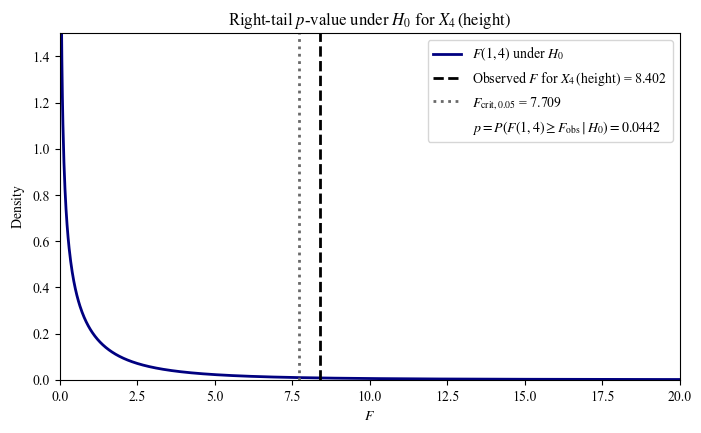

In [86]:
# Ensure the plotting range always includes the observed F value plus some right-tail space
x_max = max(20, float(f_value) * 1.25 + 1)
x = np.linspace(0.001, x_max, 1200)

# Format factor name for math rendering.
selected_factor_tex = factor_to_tex(selected_factor, wrap_math=False)

plt.figure(figsize=(8, 4.5))
if SCIPY_AVAILABLE:
    y = f_dist.pdf(x, 1, df_error)
    plt.plot(x, y, color="navy", linewidth=2, label=r"$F(1,4)$ under $H_0$")

    # Observed F line in black.
    plt.axvline(
        f_value, color="black", linestyle="--", linewidth=2,
        label=rf"Observed $F$ for ${selected_factor_tex}$ = {f_value:.3f}"
    )

    # Critical value for alpha = 0.05: P(F >= F_crit | H0) = 0.05
    f_crit_005 = float(f_dist.isf(0.05, 1, df_error))
    plt.axvline(
        f_crit_005,
        color="dimgray",
        linestyle=":",
        linewidth=2,
        label=rf"$F_{{\mathrm{{crit}},0.05}}$ = {f_crit_005:.3f}"
    )

    p_tail = float(f_dist.sf(f_value, 1, df_error))
    formula_label = rf"$p = P(F(1,4) \geq F_{{\mathrm{{obs}}}}\mid H_0) = {p_tail:.4f}$"
    plt.plot([], [], " ", label=formula_label)
else:
    plt.axvline(f_value, linestyle="--", label=rf"Observed $F$ = {f_value:.3f}")
    plt.text(0.5, 0.5, "scipy not available in this JupyterLite build", transform=plt.gca().transAxes, ha="center")

plt.xlabel(r"$F$")
plt.ylabel(r"$\mathrm{Density}$")
plt.title(rf"Right-tail $p$-value under $H_0$ for ${selected_factor_tex}$")
plt.legend()
plt.xlim(0, x_max)
plt.ylim(0, 1.5)
plt.show()

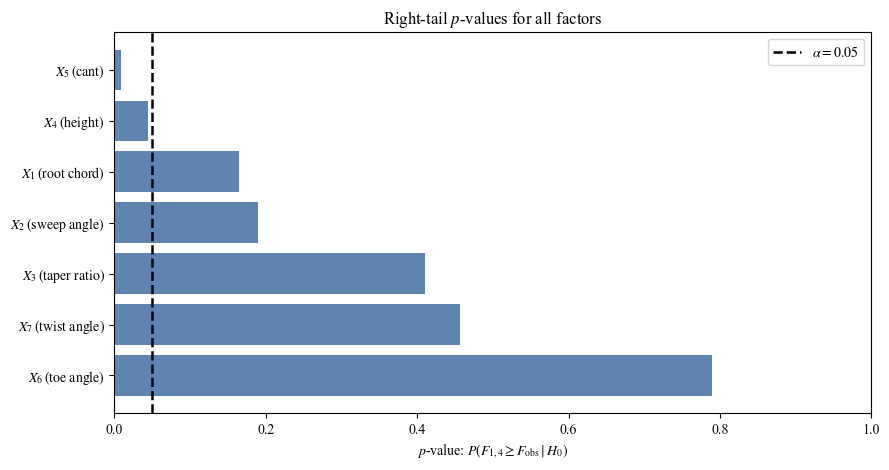

In [91]:
# Right-tail p-values for all factors
if SCIPY_AVAILABLE:
    pvals_all = results_df[["factor", "F"]].copy()
    pvals_all["p_value"] = pvals_all["F"].apply(lambda val: float(f_dist.sf(val, 1, df_error)))
    pvals_all = pvals_all.sort_values("p_value", ascending=True)

    labels = [factor_to_tex(name, wrap_math=True) for name in pvals_all["factor"]]
    ypos = np.arange(len(pvals_all))

    plt.figure(figsize=(9, 4.8))
    plt.barh(ypos, pvals_all["p_value"], color="#4C78A8", alpha=0.9)
    plt.axvline(0.05, color="black", linestyle="--", linewidth=1.8, label=r"$\alpha=0.05$")
    plt.yticks(ypos, labels)
    plt.gca().invert_yaxis()
    plt.xlabel(r"$p$-value: $P(F_{1,4} \geq F_{\mathrm{obs}} \mid H_0)$")
    plt.title(r"Right-tail $p$-values for all factors")
    plt.xlim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("This plot requires scipy (scipy.stats.f).")

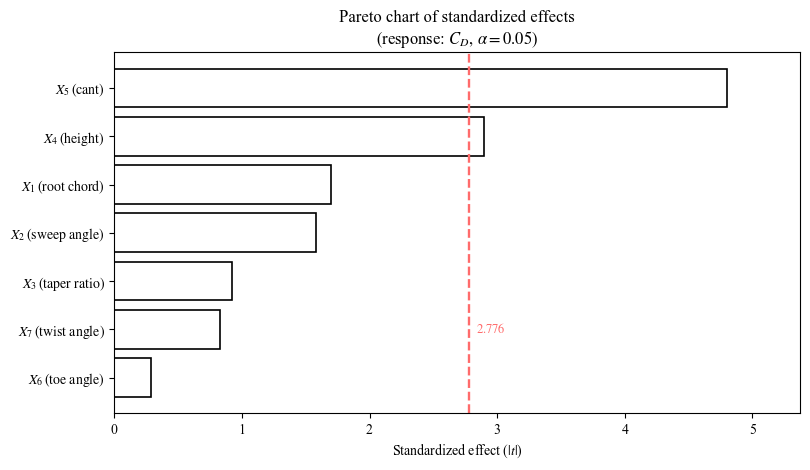

In [92]:
# Pareto chart of standardized effects (|t| = sqrt(F) for df1 = 1)
if SCIPY_AVAILABLE:
    from scipy.stats import t as t_dist

    alpha = 0.05
    t_crit = float(t_dist.ppf(1 - alpha / 2, df_error))

    pareto_df = results_df[["factor", "F"]].copy()
    pareto_df["std_effect"] = np.sqrt(pareto_df["F"])
    pareto_df = pareto_df.sort_values("std_effect", ascending=False)

    y_labels = [factor_to_tex(name, wrap_math=True) for name in pareto_df["factor"]]
    y_pos = np.arange(len(pareto_df))

    plt.figure(figsize=(8.2, 4.8))
    plt.barh(
        y_pos,
        pareto_df["std_effect"],
        color="white",
        edgecolor="black",
        linewidth=1.2
    )
    plt.yticks(y_pos, y_labels)
    plt.gca().invert_yaxis()

    plt.axvline(t_crit, color="#ff6b6b", linestyle="--", linewidth=1.7)
    twist_name = "X7_twist_angle"
    twist_y = list(pareto_df["factor"]).index(twist_name) if twist_name in list(pareto_df["factor"]) else len(pareto_df) - 2
    plt.text(
        t_crit + 0.06,
        twist_y,
        rf"${t_crit:.3f}$",
        color="#ff6b6b",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

    plt.xlabel(r"Standardized effect ($|t|$)")
    plt.title(r"Pareto chart of standardized effects" + "\n" + r"(response: $C_D$, $\alpha=0.05$)")
    plt.xlim(0, max(float(pareto_df["std_effect"].max()) * 1.12, t_crit * 1.15))
    plt.tight_layout()
    plt.show()
else:
    print("This Pareto chart requires scipy (scipy.stats.t and scipy.stats.f).")

## Reduced Model After Removing the Least Significant Factor

Following the presentation logic, we perform one-step model refinement after the full screening fit.

Procedure:
1. Identify the factor with the largest factor-level $p$-value in the full model.
2. Remove that factor.
3. Recompute ANOVA quantities and model-level significance.
4. Compare full vs reduced model diagnostics.

Why this is useful:
- simplifies interpretation,
- can improve signal-to-noise in small-sample screening,
- highlights which effects remain consistently influential.

Caution for DOE practice:
- factor removal should be supported by engineering understanding,
- in PB screening, possible aliasing/interaction contamination means removal is heuristic,
- final design decisions should be confirmed in a follow-up experiment (e.g., factorial refinement or response-surface phase).

In [84]:
# Reduced model: remove least significant factor from the full model
if SCIPY_AVAILABLE:
    least_sig_idx = results_df["p_value"].idxmax()
    removed_factor = str(results_df.loc[least_sig_idx, "factor"])
    keep_factors = [f for f in factors if f != removed_factor]

    reduced_rows = []
    for name in keep_factors:
        j = factors.index(name)
        contrast = float(np.sum(coded[:, j] * CD))
        ss = contrast**2 / 12.0
        reduced_rows.append({
            "factor": name,
            "contrast": contrast,
            "effect": contrast / 6.0,
            "SS": ss,
            "df": 1,
        })

    reduced_df = pd.DataFrame(reduced_rows)
    reduced_df["MS"] = reduced_df["SS"] / reduced_df["df"]

    SS_model_reduced = float(reduced_df["SS"].sum())
    SS_error_reduced = SS_total - SS_model_reduced
    df_model_reduced = len(keep_factors)
    df_error_reduced = df_total - df_model_reduced
    MS_error_reduced = SS_error_reduced / df_error_reduced

    reduced_df["F"] = reduced_df["MS"] / MS_error_reduced
    reduced_df["p_value"] = reduced_df["F"].apply(
        lambda x: float(f_dist.sf(x, 1, df_error_reduced))
    )

    MS_model_reduced = SS_model_reduced / df_model_reduced
    F_model_reduced = MS_model_reduced / MS_error_reduced
    p_model_reduced = float(f_dist.sf(F_model_reduced, df_model_reduced, df_error_reduced))

    anova_reduced_rows = []
    for _, row in reduced_df.iterrows():
        anova_reduced_rows.append({
            "source": row["factor"],
            "SS": float(row["SS"]),
            "df": int(row["df"]),
            "MS": float(row["MS"]),
            "F": float(row["F"]),
            "p_value": float(row["p_value"]),
        })

    anova_reduced_rows.extend([
        {
            "source": "Model",
            "SS": float(SS_model_reduced),
            "df": int(df_model_reduced),
            "MS": float(MS_model_reduced),
            "F": float(F_model_reduced),
            "p_value": float(p_model_reduced),
        },
        {
            "source": "Error",
            "SS": float(SS_error_reduced),
            "df": int(df_error_reduced),
            "MS": float(MS_error_reduced),
            "F": np.nan,
            "p_value": np.nan,
        },
        {
            "source": "Total",
            "SS": float(SS_total),
            "df": int(df_total),
            "MS": np.nan,
            "F": np.nan,
            "p_value": np.nan,
        },
    ])

    anova_reduced_df = pd.DataFrame(anova_reduced_rows).fillna("")
    anova_reduced_df["source"] = anova_reduced_df["source"].apply(
        lambda s: factor_to_html(s) if isinstance(s, str) and s.startswith("X") else s
    )
    anova_reduced_df = anova_reduced_df.rename(columns={
        "source": "Source",
        "p_value": "p-value",
    })

    comparison_df = pd.DataFrame([
        {
            "model": "Full",
            "removed_factor": "-",
            "df_model": int(df_model),
            "df_error": int(df_error),
            "MS_error": float(MS_error),
            "F_model": float(F_model),
            "p_model": float(p_model),
        },
        {
            "model": "Reduced",
            "removed_factor": removed_factor,
            "df_model": int(df_model_reduced),
            "df_error": int(df_error_reduced),
            "MS_error": float(MS_error_reduced),
            "F_model": float(F_model_reduced),
            "p_model": float(p_model_reduced),
        },
    ])
    comparison_df["removed_factor"] = comparison_df["removed_factor"].apply(
        lambda s: factor_to_html(s) if isinstance(s, str) and s.startswith("X") else s
    )
    comparison_df = comparison_df.rename(columns={
        "model": "Model",
        "removed_factor": "Removed factor",
        "p_model": "Model p-value",
    })

    print(f"Removed factor (least significant in full model): {removed_factor}")
    print()
    print("Model-level comparison")
    display(HTML(comparison_df.to_html(index=False, escape=False)))
    print("Reduced-model ANOVA table")
    display(HTML(anova_reduced_df.to_html(index=False, escape=False)))
else:
    print("Reduced-model ANOVA with model p-values requires scipy.")

Removed factor (least significant in full model): X6_toe_angle

Model-level comparison


Model,Removed factor,df_model,df_error,MS_error,F_model,Model p-value
Full,-,7,4,4.242197e-07,5.485845,0.059642
Reduced,X6 (toe angle),6,5,3.462452e-07,7.824937,0.019637


Reduced-model ANOVA table


Source,SS,df,MS,F,p-value
X1 (root chord),1.227520e-06,1,0.000001,3.545234,0.118438
X2 (sweep angle),1.054947e-06,1,0.000001,3.046821,0.141337
X3 (taper ratio),3.577653e-07,1,0.0,1.033272,0.356028
X4 (height),3.564300e-06,1,0.000004,10.29415,0.02377
X5 (cant),9.763248e-06,1,0.00001,28.197497,0.003166
X7 (twist angle),2.883000e-07,1,0.0,0.832647,0.40336
Model,1.625608e-05,6,0.000003,7.824937,0.019637
Error,1.731226e-06,5,0.0,,
Total,1.798731e-05,11,,,


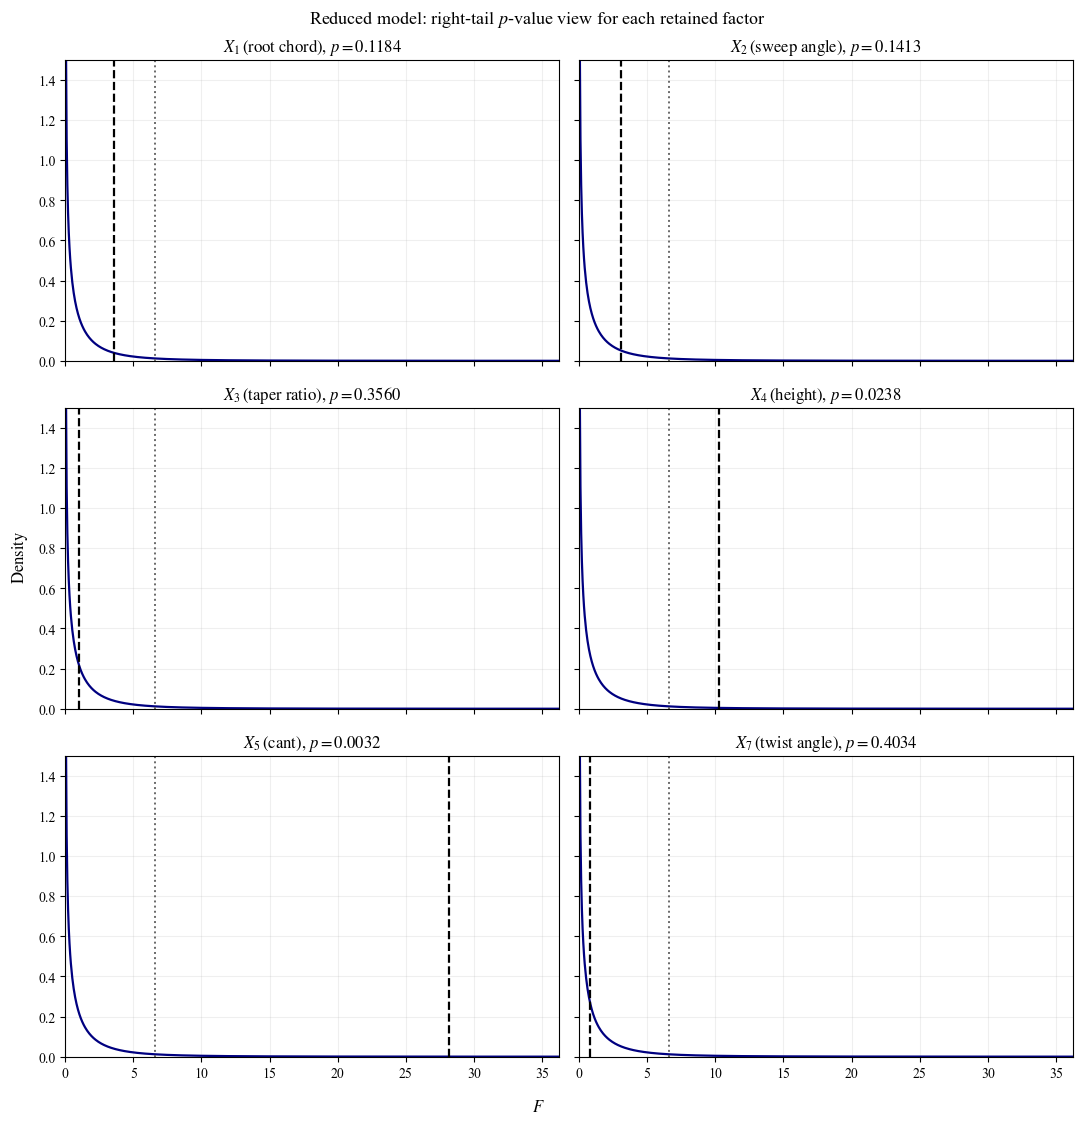

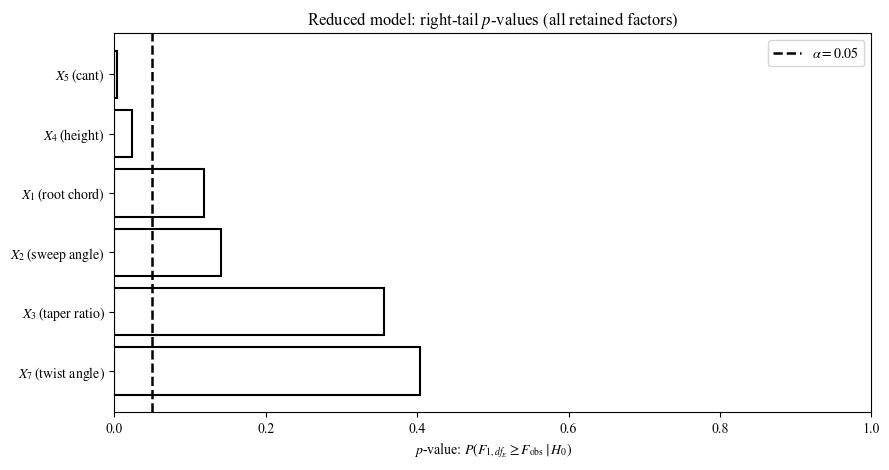

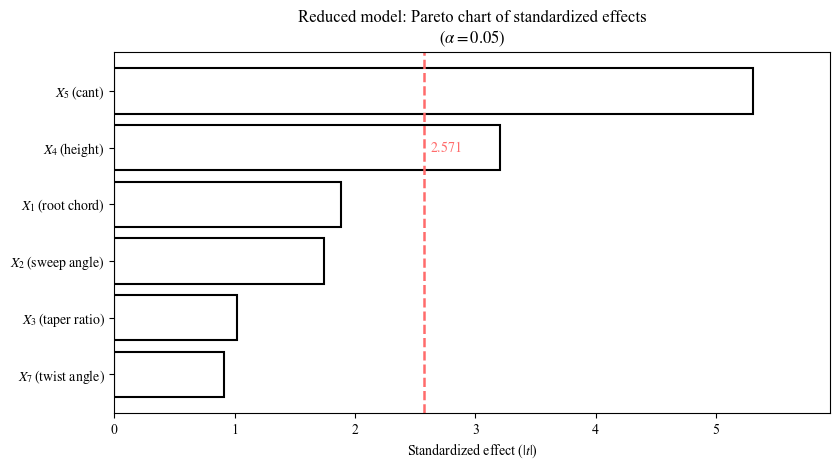

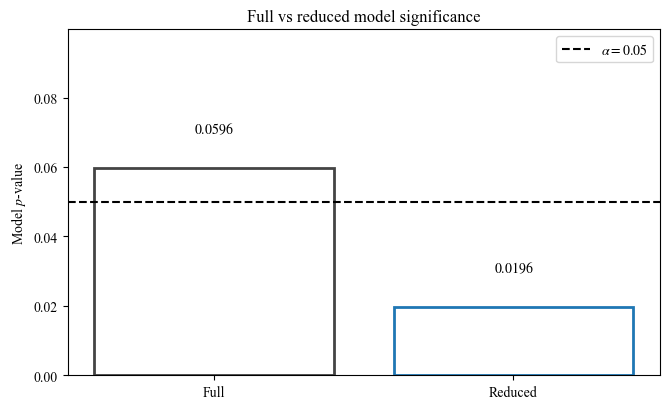

In [93]:
# Reduced-model visualization suite
if not SCIPY_AVAILABLE:
    print("These plots require scipy.")
elif "reduced_df" not in globals() or "df_error_reduced" not in globals():
    print("Run the reduced-model cell first (Cell 19), then run this cell.")
else:
    # Keep a local style context so notebook-global settings can still be overridden if needed.
    style_rc = {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False,
    }

    with plt.rc_context(style_rc):
        # ---------- 1) Right-tail p-value graph for each retained factor (subplots) ----------
        reduced_plot_df = reduced_df.copy().sort_values("factor")
        n = len(reduced_plot_df)
        ncols = 2
        nrows = int(np.ceil(n / ncols))

        x_max_each = max(20, float(reduced_plot_df["F"].max()) * 1.25 + 1)
        x = np.linspace(0.001, x_max_each, 700)
        y = f_dist.pdf(x, 1, df_error_reduced)
        f_crit_each = float(f_dist.isf(0.05, 1, df_error_reduced))

        fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.8 * nrows), sharex=True, sharey=True)
        axes = np.atleast_1d(axes).ravel()

        for ax, (_, row) in zip(axes, reduced_plot_df.iterrows()):
            f_obs = float(row["F"])
            p_obs = float(row["p_value"])
            factor = str(row["factor"])
            factor_tex = factor_to_tex(factor, wrap_math=False)
            ax.plot(x, y, color="navy", linewidth=1.6)
            ax.axvline(f_obs, color="black", linestyle="--", linewidth=1.6)
            ax.axvline(f_crit_each, color="dimgray", linestyle=":", linewidth=1.4)
            ax.set_title(rf"${factor_tex}$, $p={p_obs:.4f}$")
            ax.set_xlim(0, x_max_each)
            ax.set_ylim(0, 1.5)
            ax.grid(alpha=0.2)

        for ax in axes[n:]:
            ax.axis("off")

        fig.suptitle(r"Reduced model: right-tail $p$-value view for each retained factor", fontsize=13)
        fig.supxlabel(r"$F$")
        fig.supylabel(r"$\mathrm{Density}$")
        plt.tight_layout()
        plt.show()

        # ---------- 2) One right-tail p-value plot with all retained factors ----------
        pvals_reduced = reduced_df[["factor", "p_value"]].copy().sort_values("p_value", ascending=True)
        ypos = np.arange(len(pvals_reduced))
        ylabels = [factor_to_tex(name, wrap_math=True) for name in pvals_reduced["factor"]]

        plt.figure(figsize=(9, 4.8))
        plt.barh(
            ypos,
            pvals_reduced["p_value"],
            facecolor="none",
            edgecolor="black",
            linewidth=1.5
        )
        plt.axvline(0.05, color="black", linestyle="--", linewidth=1.8, label=r"$\alpha=0.05$")
        plt.yticks(ypos, ylabels)
        plt.gca().invert_yaxis()
        plt.xlabel(r"$p$-value: $P(F_{1,df_E} \geq F_{\mathrm{obs}} \mid H_0)$")
        plt.title(r"Reduced model: right-tail $p$-values (all retained factors)")
        plt.xlim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # ---------- 3) Pareto chart for reduced model ----------
        from scipy.stats import t as t_dist
        alpha = 0.05
        t_crit_reduced = float(t_dist.ppf(1 - alpha / 2, df_error_reduced))

        pareto_reduced = reduced_df[["factor", "F"]].copy()
        pareto_reduced["std_effect"] = np.sqrt(pareto_reduced["F"])
        pareto_reduced = pareto_reduced.sort_values("std_effect", ascending=False)
        ylabels_pareto = [factor_to_tex(name, wrap_math=True) for name in pareto_reduced["factor"]]

        plt.figure(figsize=(8.5, 4.8))
        y_pos = np.arange(len(pareto_reduced))
        plt.barh(
            y_pos,
            pareto_reduced["std_effect"],
            facecolor="none",
            edgecolor="black",
            linewidth=1.5
        )
        plt.yticks(y_pos, ylabels_pareto)
        plt.gca().invert_yaxis()
        plt.axvline(t_crit_reduced, color="#ff6b6b", linestyle="--", linewidth=1.8)
        plt.text(
            t_crit_reduced + 0.05,
            min(len(pareto_reduced) - 1, 1),
            rf"${t_crit_reduced:.3f}$",
            color="#ff6b6b",
            va="center",
            ha="left",
            fontweight="bold"
        )
        plt.xlabel(r"Standardized effect ($|t|$)")
        plt.title(r"Reduced model: Pareto chart of standardized effects" + "\n" + r"($\alpha=0.05$)")
        plt.xlim(0, max(float(pareto_reduced["std_effect"].max()) * 1.12, t_crit_reduced * 1.15))
        plt.tight_layout()
        plt.show()

        # ---------- 4) Extra plot: full vs reduced model p-value comparison ----------
        model_comp_plot = pd.DataFrame([
            {"model": "Full", "p_model": float(p_model)},
            {"model": "Reduced", "p_model": float(p_model_reduced)}
        ])

        plt.figure(figsize=(6.8, 4.2))
        plt.bar(
            model_comp_plot["model"],
            model_comp_plot["p_model"],
            facecolor="none",
            edgecolor=["#444444", "#1f77b4"],
            linewidth=2
        )
        plt.axhline(0.05, color="black", linestyle="--", linewidth=1.5, label=r"$\alpha=0.05$")
        for i, val in enumerate(model_comp_plot["p_model"]):
            plt.text(i, val + 0.01, rf"${val:.4f}$", ha="center")
        plt.ylim(0, max(0.08, float(model_comp_plot["p_model"].max()) + 0.04))
        plt.ylabel(r"Model $p$-value")
        plt.title(r"Full vs reduced model significance")
        plt.legend()
        plt.tight_layout()
        plt.show()